In [1]:
from pathlib import Path

dataset_path = Path(
    r"C:\Users\admin\Downloads\deep learning\archive\archive\animals"
)

print("Dataset path:", dataset_path)
print("Exists:", dataset_path.exists())

print("\nClasses:")
for folder in dataset_path.iterdir():
    if folder.is_dir():
        print(folder.name)

Dataset path: C:\Users\admin\Downloads\deep learning\archive\archive\animals
Exists: True

Classes:
cats
dogs
panda


In [2]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for class_folder in dataset_path.iterdir():

    if class_folder.is_dir():

        images = [
            file for file in class_folder.rglob("*")
            if file.suffix.lower() in image_extensions
        ]

        print(f"{class_folder.name}: {len(images)} images")

cats: 1000 images
dogs: 1000 images
panda: 1000 images


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from PIL import Image
import random


In [4]:
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce MX550
CUDA version: 12.4


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [6]:
IMAGE_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

In [7]:
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)
print("Total images:", len(full_dataset))

Classes: ['cats', 'dogs', 'panda']
Class mapping: {'cats': 0, 'dogs': 1, 'panda': 2}
Total images: 3000


In [8]:
total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 2100
Validation: 450
Testing: 450


In [9]:
full_dataset_no_aug = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices
test_indices = test_dataset.indices

In [10]:
from torch.utils.data import Subset

train_dataset = Subset(
    full_dataset,
    train_indices
)

val_dataset = Subset(
    full_dataset_no_aug,
    val_indices
)

test_dataset = Subset(
    full_dataset_no_aug,
    test_indices
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 2100
Validation: 450
Testing: 450


In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


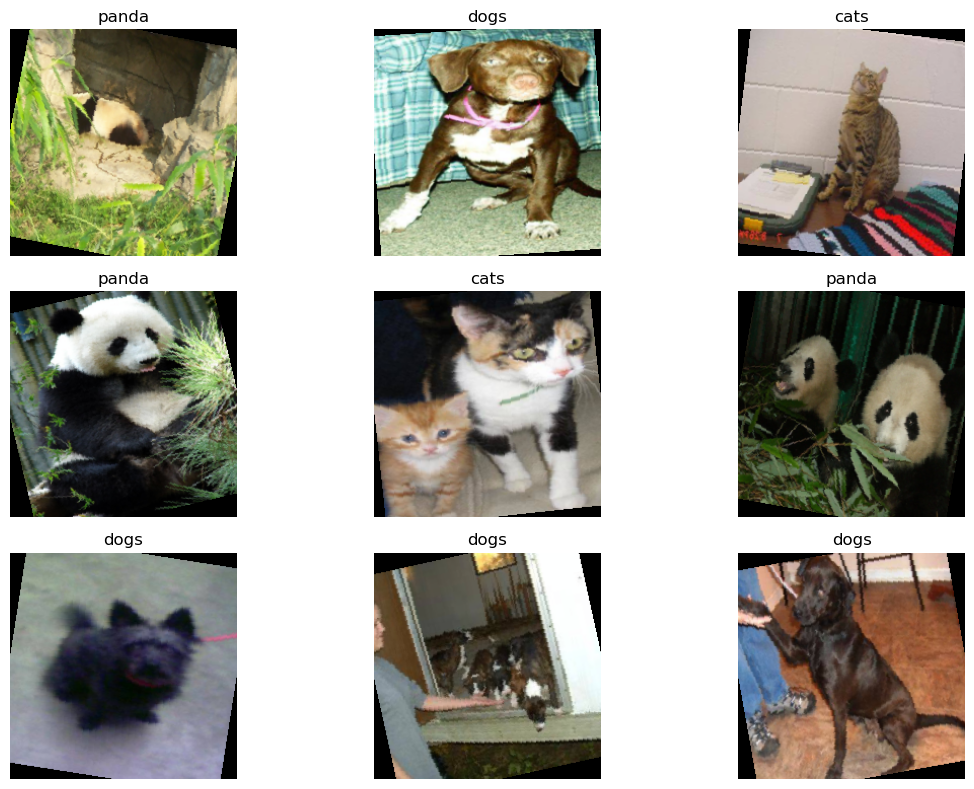

In [12]:
class_names = full_dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):

    image = images[i].permute(1, 2, 0).numpy()

    image = image * np.array(imagenet_std)
    image = image + np.array(imagenet_mean)

    image = np.clip(image, 0, 1)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
weights = ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

print("Pretrained ResNet18 loaded.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:07<00:00, 5.93MB/s]


Pretrained ResNet18 loaded.


In [14]:
for param in model.parameters():
    param.requires_grad = False

print("All pretrained layers frozen.")

All pretrained layers frozen.


In [15]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 3)
)

print(model.fc)

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=3, bias=True)
)


In [16]:
model = model.to(device)

print(
    "Model is running on:",
    next(model.parameters()).device
)

Model is running on: cuda:0


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [20]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Optimizer ready.")

Optimizer ready.


In [24]:
from torch.utils.data import Subset

MAX_PER_CLASS = 400

selected_indices = []

for class_id in range(3):

    class_indices = [
        i for i, (_, label) in enumerate(full_dataset.samples)
        if label == class_id
    ]

    random.seed(SEED)
    random.shuffle(class_indices)

    selected_indices.extend(
        class_indices[:MAX_PER_CLASS]
    )

random.shuffle(selected_indices)

# Split indices
total_size = len(selected_indices)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)

train_indices = selected_indices[:train_size]
val_indices = selected_indices[
    train_size:train_size + val_size
]
test_indices = selected_indices[
    train_size + val_size:
]

train_dataset = Subset(
    full_dataset,
    train_indices
)

val_dataset = Subset(
    full_dataset_no_aug,
    val_indices
)

test_dataset = Subset(
    full_dataset_no_aug,
    test_indices
)

print("Total:", len(selected_indices))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Total: 1200
Train: 840
Validation: 180
Test: 180


In [25]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Fast DataLoaders ready.")

Fast DataLoaders ready.


In [26]:
NUM_EPOCHS = 10

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

checkpoint_path = "best_cat_dog_panda_resnet18.pth"

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "val_accuracy": val_accuracy,
            "epoch": epoch + 1
        }, checkpoint_path)

        print("✓ Best model saved!")

Epoch [1/10] | Train Loss: 0.0762 | Train Acc: 96.90% | Val Loss: 0.0650 | Val Acc: 98.33%
✓ Best model saved!
Epoch [2/10] | Train Loss: 0.0766 | Train Acc: 96.90% | Val Loss: 0.0597 | Val Acc: 97.78%
Epoch [3/10] | Train Loss: 0.0536 | Train Acc: 97.98% | Val Loss: 0.0633 | Val Acc: 97.78%
Epoch [4/10] | Train Loss: 0.0796 | Train Acc: 97.74% | Val Loss: 0.0645 | Val Acc: 97.78%
Epoch [5/10] | Train Loss: 0.0656 | Train Acc: 97.38% | Val Loss: 0.0527 | Val Acc: 97.22%
Epoch [6/10] | Train Loss: 0.1323 | Train Acc: 95.36% | Val Loss: 0.0550 | Val Acc: 97.22%
Epoch [7/10] | Train Loss: 0.0650 | Train Acc: 98.21% | Val Loss: 0.0778 | Val Acc: 97.22%
Epoch [8/10] | Train Loss: 0.0610 | Train Acc: 97.74% | Val Loss: 0.0450 | Val Acc: 98.33%
Epoch [9/10] | Train Loss: 0.0717 | Train Acc: 97.62% | Val Loss: 0.0342 | Val Acc: 98.33%
Epoch [10/10] | Train Loss: 0.0592 | Train Acc: 97.86% | Val Loss: 0.0747 | Val Acc: 96.67%


In [27]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best model loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print(
    f"Best validation accuracy: "
    f"{checkpoint['val_accuracy']:.2f}%"
)

C:\Users\admin\AppData\Local\Temp\ipykernel_25468\1847387372.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Best model loaded successfully.
Best epoch: 1
Best validation accuracy: 98.33%


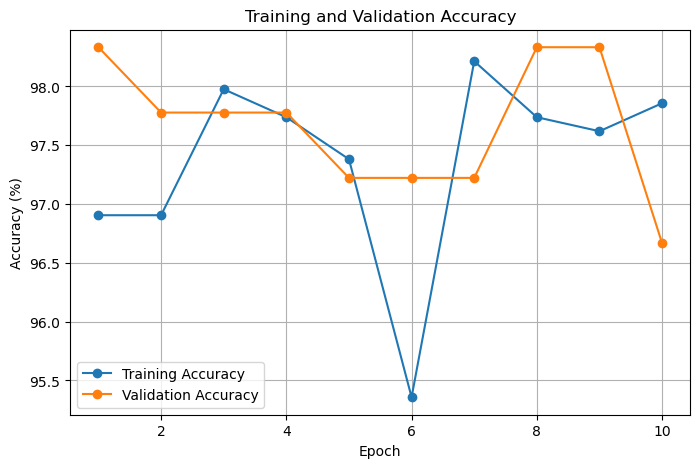

In [28]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

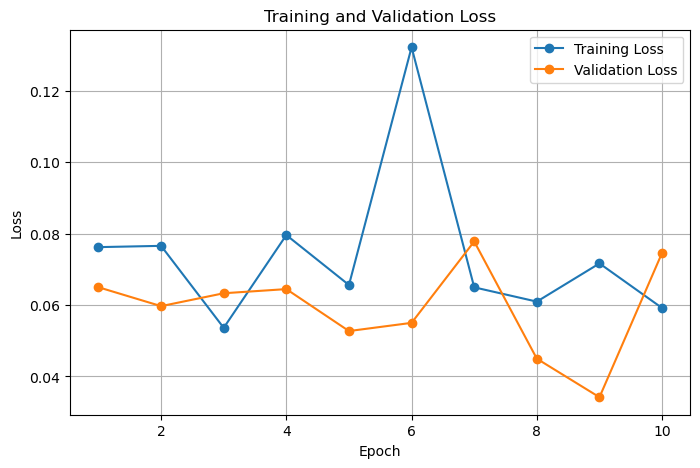

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [30]:
def evaluate_test(model, loader, criterion, device):
    
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, predictions = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
            
            all_predictions.extend(
                predictions.cpu().numpy()
            )
            
            all_labels.extend(
                labels.cpu().numpy()
            )
    
    test_loss = running_loss / total
    test_accuracy = 100 * correct / total
    
    return (
        test_loss,
        test_accuracy,
        np.array(all_labels),
        np.array(all_predictions)
    )

In [31]:
test_loss, test_accuracy, y_true, y_pred = evaluate_test(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0556
Test Accuracy: 97.22%


In [32]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        cats       0.98      0.93      0.95        54
        dogs       0.93      0.98      0.96        57
       panda       1.00      1.00      1.00        69

    accuracy                           0.97       180
   macro avg       0.97      0.97      0.97       180
weighted avg       0.97      0.97      0.97       180



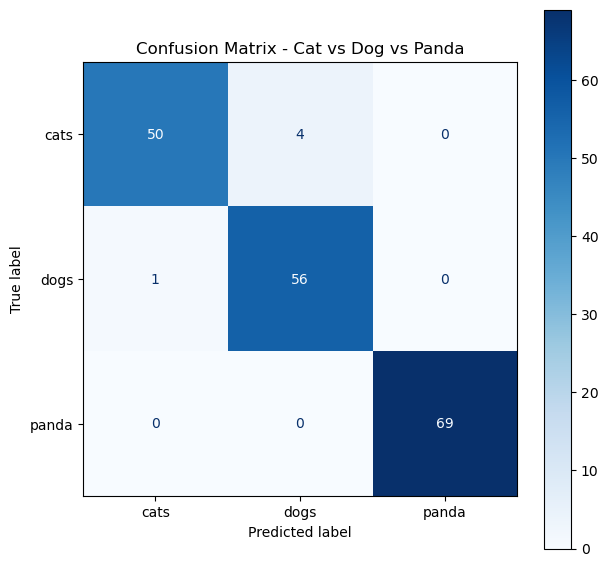

In [33]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Cat vs Dog vs Panda")
plt.show()

In [34]:
def predict_image(
    model,
    image_path,
    transform,
    class_names,
    device
):
    
    image = Image.open(image_path).convert("RGB")
    
    image_tensor = transform(image).unsqueeze(0)
    image_tensor = image_tensor.to(device)
    
    model.eval()
    
    with torch.no_grad():
        
        output = model(image_tensor)
        
        probabilities = torch.softmax(
            output,
            dim=1
        )
        
        confidence, predicted_class = torch.max(
            probabilities,
            1
        )
    
    predicted_label = class_names[
        predicted_class.item()
    ]
    
    return (
        image,
        predicted_label,
        confidence.item()
    )

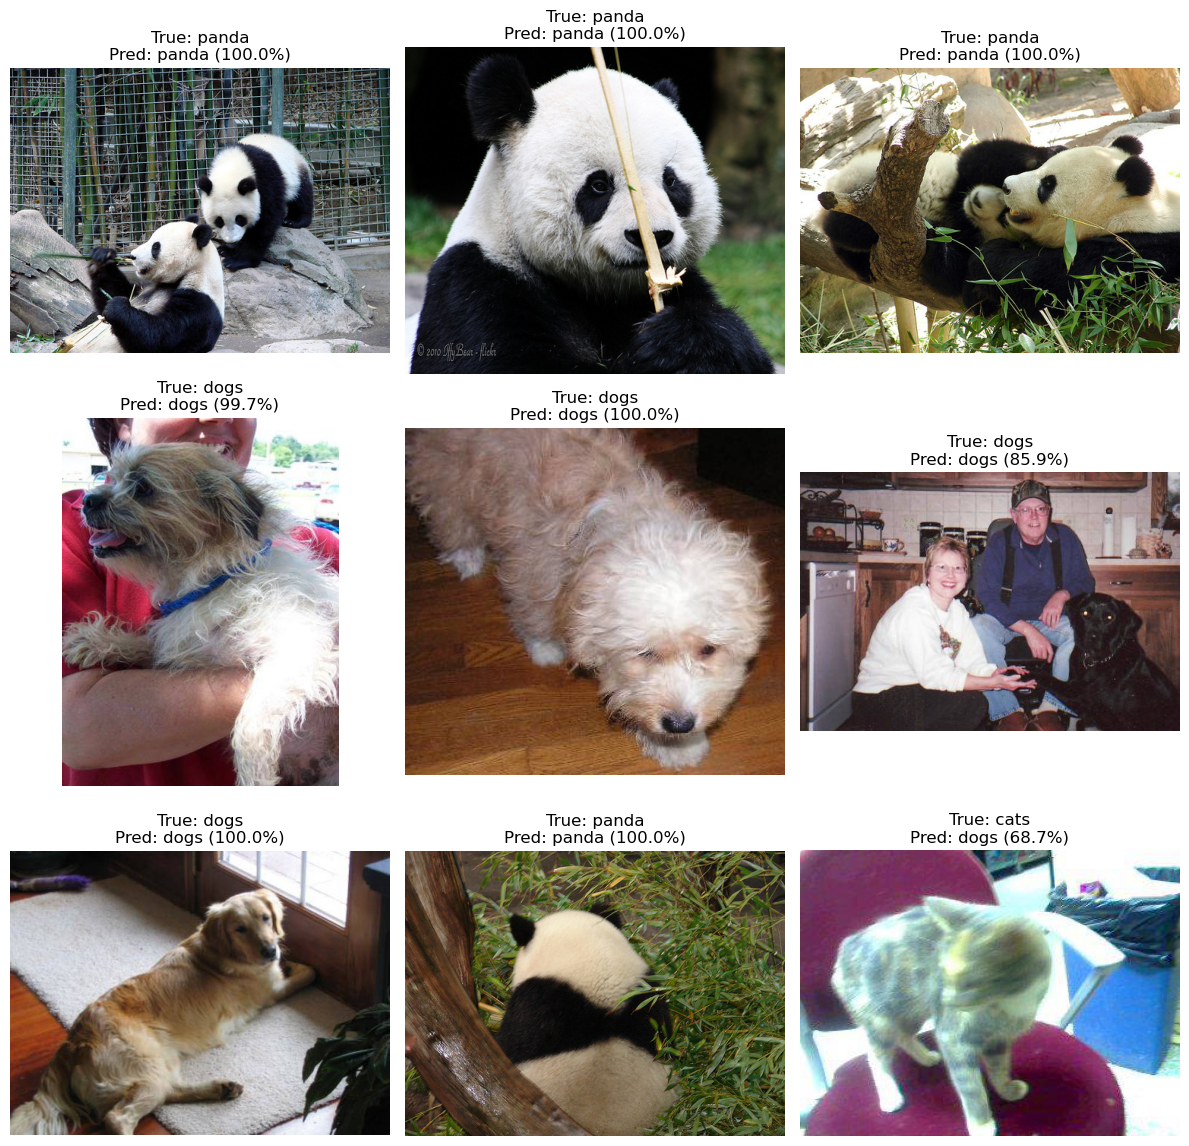

In [35]:
num_examples = 9

indices = random.sample(
    range(len(test_dataset)),
    num_examples
)

plt.figure(figsize=(12, 12))

for i, index in enumerate(indices):
    
    image_path, true_label_index = test_dataset.dataset.samples[
        test_dataset.indices[index]
    ]
    
    image, predicted_label, confidence = predict_image(
        model,
        image_path,
        test_transform,
        class_names,
        device
    )
    
    true_label = class_names[true_label_index]
    
    plt.subplot(3, 3, i + 1)
    
    plt.imshow(image)
    
    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label} "
        f"({confidence * 100:.1f}%)"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
final_model_path = "cat_dog_panda_resnet18_final.pth"

torch.save(
    model.state_dict(),
    final_model_path
)

print(
    "Final model saved as:",
    final_model_path
)

Final model saved as: cat_dog_panda_resnet18_final.pth


In [37]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print("Model: ResNet18 Transfer Learning")
print("Classes:", class_names)
print("Total Images:", len(full_dataset))
print("Epochs:", NUM_EPOCHS)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("=" * 50)

FINAL MODEL RESULTS
Model: ResNet18 Transfer Learning
Classes: ['cats', 'dogs', 'panda']
Total Images: 3000
Epochs: 10
Best Validation Accuracy: 98.33%
Test Loss: 0.0556
Test Accuracy: 97.22%
Device: cuda
GPU: NVIDIA GeForce MX550
